# Simple Linear Regression

In [1]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [3]:
# Read the dataset
df = pd.read_csv('data/height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


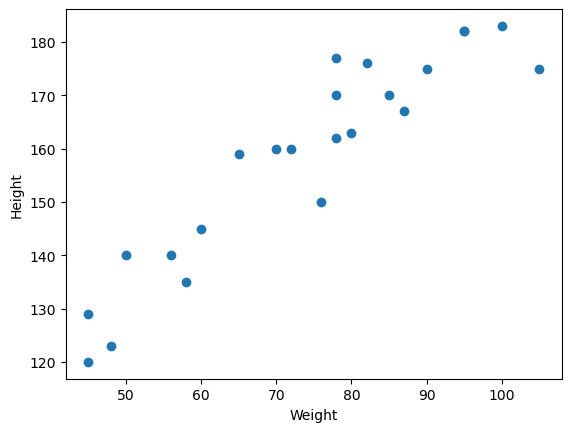

In [4]:
# Visualize the data
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [5]:
# we can clearly see from this plot, when weight is increasing, height is also increasing. to see more clearly use correlation.
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [6]:
# checking null values
df.isnull().sum()

Weight    0
Height    0
dtype: int64

In [7]:
# describe the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


In [8]:
# let's divide the data into independent and depdendent features
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X.shape, y.shape

((23, 1), (23,))

In [11]:
X[:5]

,Weight
0,45
1,58
2,48
3,60
4,70


In [12]:
y[:5]

0    120
1    135
2    123
3    145
4    160
Name: Height, dtype: int64

In [13]:
# split the data into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [14]:
# let's see the data, the range of my data is 45-95. weight is in kg unit and height is in cm unit. to avoid this difference we scale the features in 0-1
X_train.min(), X_test.max()

(Weight    45
 dtype: int64,
 Weight    95
 dtype: int64)

In [16]:
# Standardize the data (standardization = x - mean(x) / std(x) )
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# fit_transform the train data 
X_train = scaler.fit_transform(X_train)
# transform the test data (as you don't want your model to see the test data)
X_test = scaler.transform(X_test)
X_train[:5], X_test[:5]

(array([[ 1.73689094],
        [-0.92026952],
        [ 1.4542143 ],
        [ 0.21043706],
        [-1.48562281]]),
 array([[ 0.21043706],
        [ 0.21043706],
        [-1.6552288 ],
        [ 1.17153765],
        [-0.52452222]]))

In [17]:
# fit the data into linear model
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train, y_train)


LinearRegression()

In [18]:
# Coefficient and intercepts
print('Coefficent: ', regression.coef_)
print('Intercept: ', regression.intercept_)

Coefficent:  [17.03440872]
Intercept:  157.5


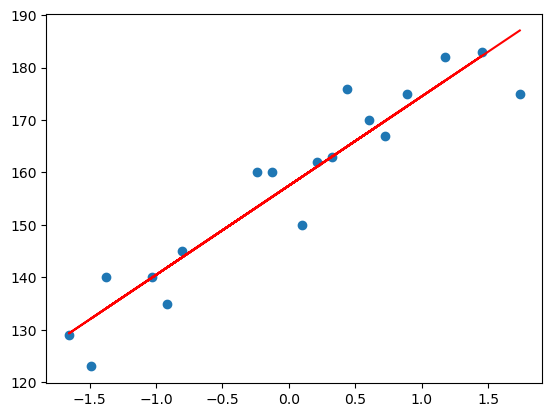

In [23]:
# see the best fit line of our model on training data
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), color='red')
plt.show()

In [22]:
# prediction of the test data
y_pred = regression.predict(X_test)
y_pred[:5]

array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
       148.56507414])

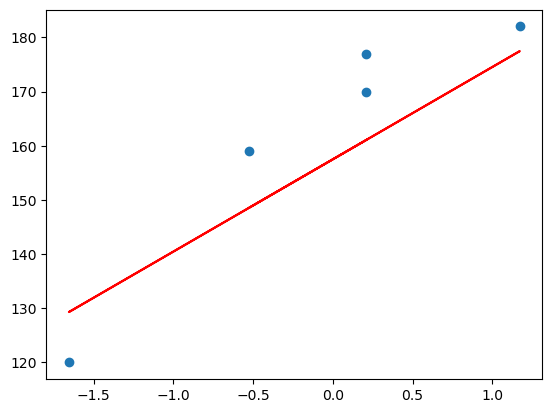

In [24]:
# see the best fit line of our model on test data
plt.scatter(X_test, y_test)
plt.plot(X_test, regression.predict(X_test), color='red')
plt.show()

In [25]:
# Evaluating the model using performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2_score = r2_score(y_test, y_pred)
adjusted_r2_score = 1 - (1-r2_score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R Squared: ", r2_score)
print("Adjusted R Squared: ", adjusted_r2_score)

MAE:  9.822657814519232
MSE:  109.77592599051658
RMSE:  10.477400726827078
R Squared:  0.776986986042344
Adjusted R Squared:  0.7026493147231252


In [26]:
# Residuals
residuals = y_test - y_pred
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

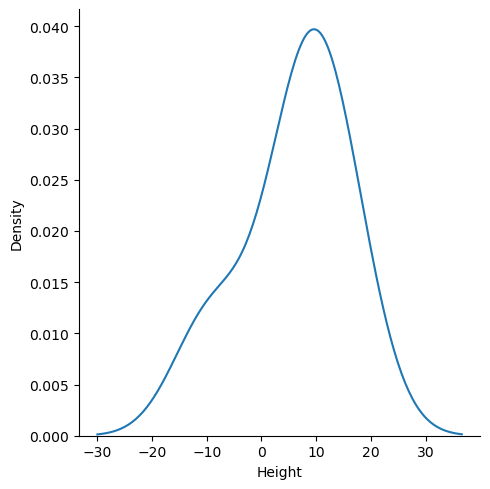

In [27]:
# Plot the residuals
sns.displot(residuals, kind='kde')
plt.show()

## Using OLS


In [39]:
import statsmodels.api as sm
model = sm.OLS(y_train, X_train).fit()
predictions = model.predict(X_test)
model.summary()


C:\Users\vrudi\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.047
Method:                 Least Squares   F-statistic:                             0.1986
Date:                Wed, 28 Jan 2026   Prob (F-statistic):                       0.661
Time:                        16:39:47   Log-Likelihood:                         -116.62
No. Observations:                  18   AIC:                                      235.2
Df Residuals:                      17   BIC:                                      236.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            17.0344     38.226      0.446      0.661     -63.616      97.684
==============================================================================
Omnibus:                        0.849   Durbin-Watson:                   0.003
Prob(Omnibus):                  0.654   Jarque-Bera (JB):                0.661
Skew:                          -0.428   Prob(JB):                        0.718
Kurtosis:                       2.614   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""